# Discrete Markov Chains and Metropolis-Hastings

This notebook introduces two foundational ideas in probabilistic modelling:

1. **Discrete Markov chains** — how a system governed by fixed transition probabilities evolves over time, and how to compute the stationary distribution analytically (linear system and eigendecomposition) and by simulation.
2. **Metropolis-Hastings (MH) sampling** — a general-purpose MCMC algorithm that can draw samples from any distribution we can evaluate pointwise, demonstrated on a bimodal Gaussian mixture.

These ideas underpin the particle MCMC and NUTS-based Heston calibration in the later notebooks in this series.

In [105]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


## 1. Discrete Markov Chains

We define a two-state chain with transition matrix

$$P = \begin{pmatrix} 0.9 & 0.1 \\ 0.3 & 0.7 \end{pmatrix}$$

The theoretical stationary distribution satisfies $\pi P = \pi$ with $\pi_0 + \pi_1 = 1$, giving $\pi = (0.75,\, 0.25)$.

### Simulation
Running the chain for 100 000 steps and tracking the running fraction of time spent in state 1 confirms convergence to $\pi_1 = 0.25$.

In [ ]:
p = [[0.9, 0.1], [0.3, 0.7]]
states = [0, 1]

chain = [0]
for i in range(100_000):
    chain.append(int(np.random.choice(states, p=p[chain[-1]])))

running_fraction = np.cumsum(chain) / np.arange(1, len(chain) + 1)
plt.plot(running_fraction, label='Running fraction in state 1')
plt.axhline(0.25, color='red', linestyle='--', label='Theoretical π₁ = 0.25')
plt.xlabel('Step')
plt.ylabel('Fraction of time in state 1')
plt.title('Markov chain convergence to stationary distribution')
plt.legend()
plt.tight_layout()
plt.show()

### Analytical stationary distribution

Two equivalent approaches confirm the simulation result:

- **Linear system**: rearrange $\pi(P - I) = 0$ and replace one equation with the normalisation constraint $\sum_i \pi_i = 1$, then solve with `np.linalg.solve`.
- **Eigendecomposition**: $\pi$ is the left eigenvector of $P$ with eigenvalue 1 (equivalently, the right eigenvector of $P^\top$), normalised to sum to 1.

In [ ]:
P = np.array([[0.9, 0.1],
              [0.3, 0.7]])

# --- Method 1: Solve the linear system πP = π, with Σπ = 1 ---
# Rearranging: π(P - I) = 0, replace one equation with the normalisation constraint
A = (P - np.eye(2)).T
A[-1] = 1          # replace last row: π₀ + π₁ = 1
b = np.zeros(2)
b[-1] = 1

pi_linear = np.linalg.solve(A, b)
print(f"Linear system:      π = {pi_linear}")

# --- Method 2: Eigendecomposition ---
# π is the left eigenvector of P with eigenvalue 1
# Left eigenvectors of P = right eigenvectors of P.T
eigenvalues, eigenvectors = np.linalg.eig(P.T)
idx = np.argmin(np.abs(eigenvalues - 1))          # find eigenvalue closest to 1
pi_eig = eigenvectors[:, idx].real
pi_eig /= pi_eig.sum()                            # normalise to sum to 1
print(f"Eigendecomposition: π = {pi_eig}")

print(f"\nBoth match simulation π₁ ≈ 0.25: {np.isclose(pi_linear, pi_eig).all()}")

## 2. Metropolis-Hastings Sampling

Metropolis-Hastings allows us to draw samples from a target distribution $\pi(x)$ that we can evaluate pointwise but cannot sample from directly.

**Algorithm (random-walk MH):**
1. From the current state $x_t$, propose $x^* = x_t + \varepsilon$, $\varepsilon \sim \mathcal{N}(0, \sigma^2)$.
2. Compute the acceptance ratio $\alpha = \pi(x^*) / \pi(x_t)$.
3. Accept with probability $\min(1, \alpha)$; otherwise stay at $x_t$.

The target here is a bimodal Gaussian mixture:
$$\pi(x) = 0.4\,\mathcal{N}(x;\,-2,\,0.7^2) + 0.6\,\mathcal{N}(x;\,2,\,1.0^2)$$

The proposal standard deviation $\sigma$ controls the trade-off between exploration and acceptance rate.

Acceptance rate: 70.06%


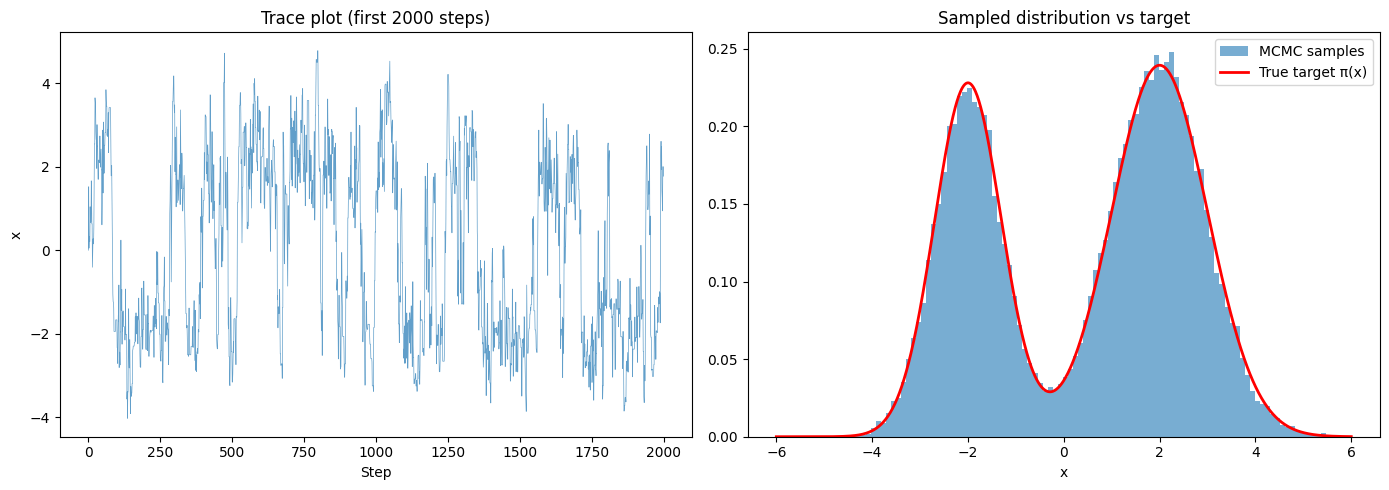

In [ ]:
# --- Target distribution ---
# A bimodal distribution: mixture of two Gaussians
# This is hard to sample from directly (no simple inverse CDF)
# but easy to evaluate at any point

def target(x):
    return 0.4 * stats.norm.pdf(x, loc=-2, scale=0.7) + 0.6 * stats.norm.pdf(x, loc=2, scale=1.0)

# --- Metropolis-Hastings ---
# Proposal: random walk, propose x* = x + noise
proposal_std = 1
n_steps = 50_000

chain = np.zeros(n_steps)
chain[0] = 0.0  # starting point

n_accepted = 0
for i in range(1, n_steps):
    current = chain[i-1]
    proposed = current + np.random.normal(0, proposal_std) # Take a random step defined by proposal_std (bigger = bigger steps, smaller = smaller steps)

    # Acceptance ratio - this is the key step
    # We only need to EVALUATE the target, not sample from it
    acceptance_ratio = target(proposed) / target(current) 

    if np.random.uniform() < acceptance_ratio:
        chain[i] = proposed
        n_accepted += 1
    else:
        chain[i] = current

# The random proposal step and the acceptance, together make up the transition probability
print(f"Acceptance rate: {n_accepted / n_steps:.2%}")

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trace plot - the chain wandering around
axes[0].plot(chain[:2000], alpha=0.7, linewidth=0.5)
axes[0].set_title("Trace plot (first 2000 steps)")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("x")

# Histogram vs true target
x_grid = np.linspace(-6, 6, 1000)
axes[1].hist(chain, bins=100, density=True, alpha=0.6, label="MCMC samples")
axes[1].plot(x_grid, target(x_grid), 'r-', linewidth=2, label="True target π(x)")
axes[1].set_title("Sampled distribution vs target")
axes[1].set_xlabel("x")
axes[1].legend()

plt.tight_layout()
plt.show()